In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Loading data

In [3]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [8]:
df.shape

(20640, 7)

# Inspecting data

In [9]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,3.422


In [6]:
df = df.drop(columns=['Latitude', 'Longitude'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Price       20640 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


In [11]:
df = df.drop_duplicates()

In [13]:
df.isna().sum().sort_values()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Price         0
dtype: int64

In [14]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# EDA

In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,5.000010


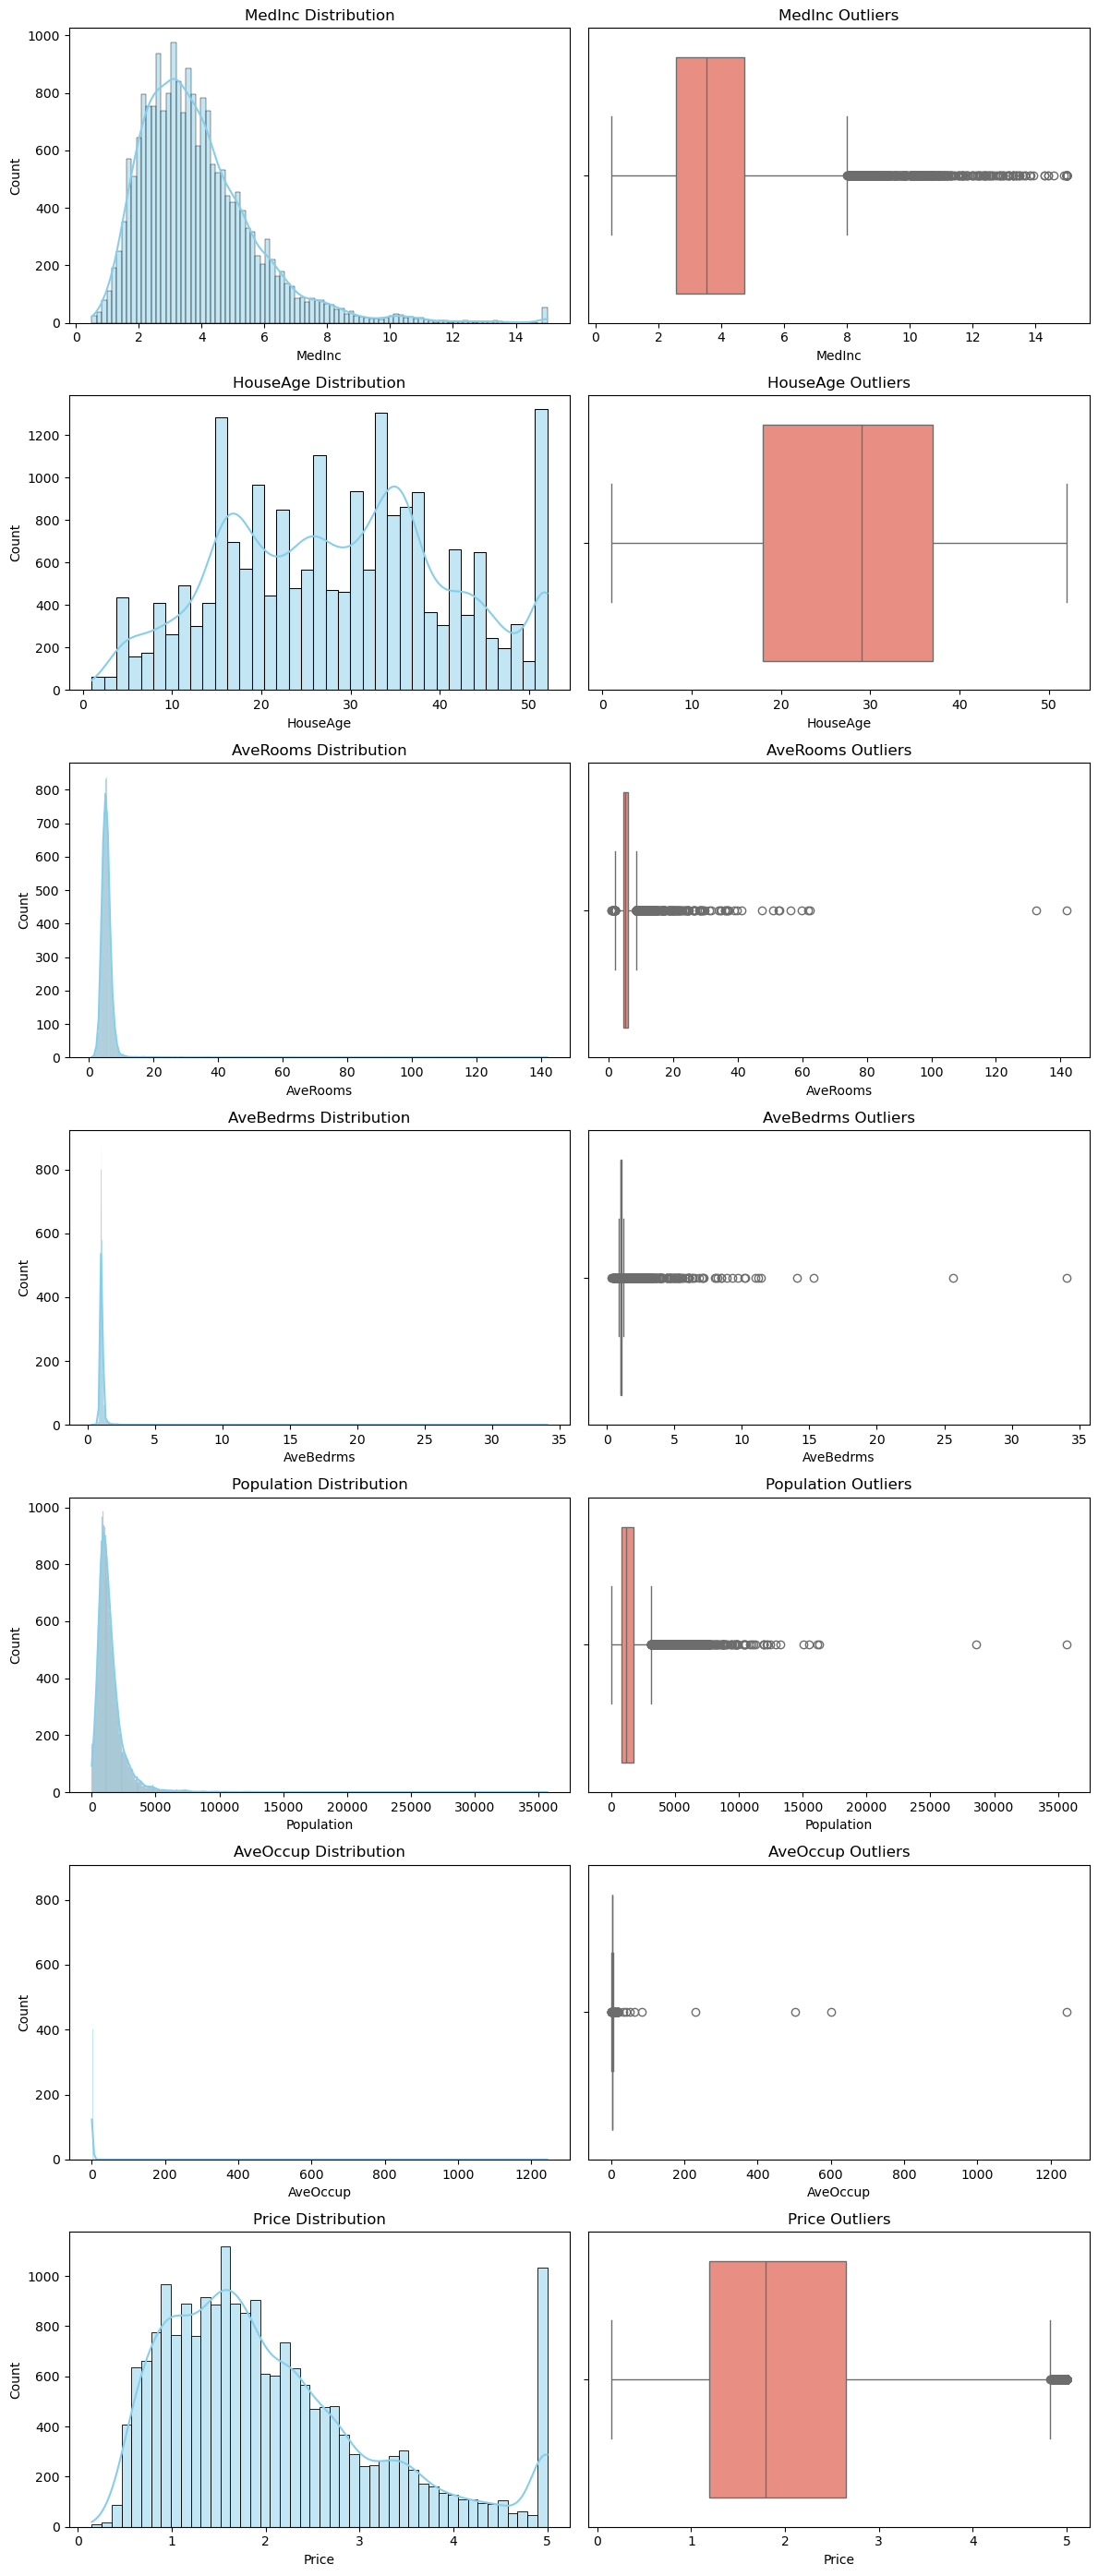

In [29]:
# 1. Identify numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Set up the figure size based on the number of columns
plt.figure(figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Plot Histogram
    plt.subplot(len(numeric_cols), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')
    plt.title(f'{col} Distribution')
    
    # Plot Boxplot
    plt.subplot(len(numeric_cols), 2, 2*i + 2)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'{col} Outliers')

plt.tight_layout()

<Axes: >

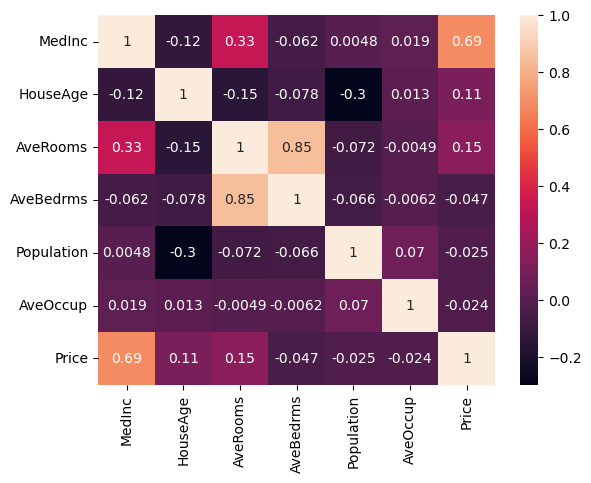

In [31]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

# Simple Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

In [40]:
X_simple = df[['MedInc']]
y_simple = df['Price']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

model_simple_lr = LinearRegression()
model_simple_lr.fit(X_train_simple, y_train_simple)

y_pred_simple_lr = model_simple_lr.predict(X_test_simple)

In [41]:
mae_simple_lr = mean_absolute_error(y_pred_simple_lr, y_test_simple)
r2_simple_lr = r2_score(y_pred_simple_lr, y_test_simple)
mse_simple_lr = mean_squared_error(y_pred_simple_lr, y_test_simple)
rmse_simple_lr = np.sqrt(mse_simple_lr)

print(f"MAE: {mae_simple_lr}")
print(f"MSE: {mse_simple_lr}")
print(f"RMSE: {rmse_simple_lr}")
print(f"R Squared: {r2_simple_lr}")

MAE: 0.629908653009376
MSE: 0.7091157771765548
RMSE: 0.8420901241414454
R Squared: -0.13940314482190175


# Multiple Linear Regression

In [34]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [36]:
mae_lr = mean_absolute_error(y_pred_lr, y_test)
r2_lr = r2_score(y_pred_lr, y_test)
mse_lr = mean_squared_error(y_pred_lr, y_test)
rmse_lr = np.sqrt(mse_lr)

print(f"MAE: {mae_lr}")
print(f"MSE: {mse_lr}")
print(f"RMSE: {rmse_lr}")
print(f"R Squared: {r2_lr}")

MAE: 0.5792140665454439
MSE: 0.6421872314534861
RMSE: 0.801365853685747
R Squared: 0.1302872196616871


# Ridge Regression

In [42]:
from sklearn.linear_model import Ridge

In [43]:
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [45]:
mae_ridge = mean_absolute_error(y_pred_ridge, y_test)
r2_ridge = r2_score(y_pred_ridge, y_test)
mse_ridge = mean_squared_error(y_pred_ridge, y_test)
rmse_ridge = np.sqrt(mse_ridge)

print(f"MAE: {mae_ridge}")
print(f"MSE: {mse_ridge}")
print(f"RMSE: {rmse_ridge}")
print(f"R Squared: {r2_ridge}")

MAE: 0.579230199587323
MSE: 0.6420746193910434
RMSE: 0.8012955880266928
R Squared: 0.13009014337492453


# Lasso Regression

In [46]:
from sklearn.linear_model import Lasso

In [48]:
lasso = Lasso()
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [49]:
mae_lasso = mean_absolute_error(y_pred_lasso, y_test)
r2_lasso = r2_score(y_pred_lasso, y_test)
mse_lasso = mean_squared_error(y_pred_lasso, y_test)
rmse_lasso = np.sqrt(mse_lasso)

print(f"MAE: {mae_lasso}")
print(f"MSE: {mse_lasso}")
print(f"RMSE: {rmse_lasso}")
print(f"R Squared: {r2_lasso}")

MAE: 0.7615782541669575
MSE: 0.9380337514945427
RMSE: 0.9685214254184276
R Squared: -10.872679150567304


In [53]:
results = {
    "Model": ["Simple Linear", "Multiple Linear", "Ridge", "Lasso"],
    "MAE": [
        mae_simple_lr,
        mae_lr,
        mae_ridge,
        mae_lasso
    ],
    "RMSE": [
        rmse_simple_lr,
        rmse_lr,
        rmse_ridge,
        rmse_lasso
    ],
    "R2": [
        r2_simple_lr,
        r2_lr,
        r2_ridge,
        r2_lasso
    ]
}

summary_df = pd.DataFrame(results)
print(summary_df)

             Model       MAE      RMSE         R2
0    Simple Linear  0.629909  0.842090  -0.139403
1  Multiple Linear  0.579214  0.801366   0.130287
2            Ridge  0.579230  0.801296   0.130090
3            Lasso  0.761578  0.968521 -10.872679


# Saving Model

In [56]:
with open('model.pkl', 'wb') as file:
    pickle.dump(model_lr, file)

# Loading Model

In [57]:
with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [62]:
new_data = np.array([[6.0650, 5.0, 5.626866, 1.062189, 1016.0, 2.527363],
                    [3.7500, 52.0, 6.117647, 1.176471, 32.0, 1.882353],
                    [5.1296, 35.0, 5.958491, 1.132075, 1012.0, 3.818868],
                    [3.5083, 52.0, 4.047836, 1.034169, 671.0, 1.528474],
                    [4.6694, 28.0, 6.181425, 1.032397, 1384.0, 2.989201]])

In [63]:
y_pred_new = loaded_model.predict(new_data)

c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
